In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

from scipy import stats
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from collections import defaultdict
from tqdm import tqdm

Parts of the analysis code (specifically the TDLM implementation) were adapted from previously published MATLAB code by Yunzhe Liu (original repository: [[link](https://github.com/YunzheLiu/TDLM)]). <br>
The code has been modified to fit the current dataset and experimental design.

# Parameters

In [2]:
np.random.seed(42)

# Parameters
n_states = 8
n_channels = 50
n_freqs = 10
n_trials = 100

n_features = n_channels * n_freqs

n_null_examples = n_trials

n_test_samples = 5000
n_sequences = 2000  # real sequences to inject
max_lag = 100  # evaluate time lag up to 600ms

c_time = np.arange(0, (max_lag + 1) * 10, 10)  # time lags in ms
n_subj = 18  # number of subjects

sample_rate = 100

gam_a = 10
gam_b = 0.5 

TF = np.eye(n_states, k=1)
TR = TF.T  # backward transition matrix

# Methods

In [3]:
def generate_unique_permutations(n_states, n_perms=1000):
    import math
    """Generate n_perms random unique permutations for shuffle testing"""
    seen = set()
    perms = []
    while len(perms) < min(n_perms, math.factorial(n_states)):
        rp = tuple(np.random.permutation(n_states))
        if rp not in seen:
            seen.add(rp)
            perms.append(rp)
    return np.array(perms)


# Generate unique permutations
unique_perms = generate_unique_permutations(n_states, 1000)
n_shuf = len(unique_perms) 

In [4]:
def train_classifier_with_overlap(n_states, n_features,  C=0.01, noise_variance=4):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    common_pattern = np.random.randn(1, n_features)
    unique_sig = np.random.randn(n_states, n_features)
    
    overlap_factors = np.array([.1,.1,.2,.25,.3,.35,.4,.45])
    overlap_patterns = np.empty_like(unique_sig)
    
    for s in range(n_states):
        m = overlap_factors[s]
        n = 1 - m
        if s == 0:
            overlap_patterns[s] = n * unique_sig[s] + m * unique_sig[s+1]
        elif s == n_states - 1:
            overlap_patterns[s] = n * unique_sig[s] + m * unique_sig[s-1]
        else:
            overlap_patterns[s] = n * unique_sig[s] + m * (unique_sig[s-1] + unique_sig[s+1]) / 2
        
        
    scale_list = np.array([1,.9,0.7,0.75,0.7,0.7,0.7,0.6])
    patterns = (1 - scale_list)[:, np.newaxis] * np.repeat(common_pattern, n_states, axis=0) + scale_list[:, np.newaxis] * overlap_patterns


    pattern_data = np.repeat(patterns, n_trials, axis=0) 
    pattern_labels = np.repeat(np.arange(1, n_states+1), n_trials, axis=0)

    null_data = np.random.randn(n_null_examples, n_features)
    null_labels = np.zeros(n_null_examples)


    training_data =  np.concatenate([pattern_data, null_data])
    training_data += np.random.randn(*training_data.shape) * noise_variance

    training_labels = np.concatenate([pattern_labels, null_labels])
    
    betas = np.zeros((n_features, n_states))
    intercepts = np.zeros(n_states)
    for i_c in range(n_states):
        y_binary = (training_labels == (i_c + 1)).astype(int)
        clf = LogisticRegression(
            penalty='l1', 
            C=C,  # C = 1/lambda
            solver='liblinear',
            fit_intercept=True,
            random_state=42,
        )
        clf.fit(training_data, y_binary)
        betas[:, i_c] = clf.coef_[0]
        intercepts[i_c] = clf.intercept_[0]

    probas = np.empty((training_data.shape[0], n_states))
    for train_idx, test_idx in cv.split(training_data, training_labels):
        for i_c in range(n_states):
            y_binary = (training_labels == (i_c + 1)).astype(int)
            clf = LogisticRegression(
                penalty='l1', 
                C=C,  # C = 1/lambda
                solver='liblinear',
                fit_intercept=True,
                random_state=42,
            )

            clf.fit(training_data[train_idx], y_binary[train_idx])
            probas[test_idx, i_c] = clf.predict_proba(training_data[test_idx])[:,1]
        
    y_pred = probas.argmax(axis=-1) + 1
    cm = confusion_matrix(training_labels[training_labels>0], y_pred[training_labels>0])
    return betas, intercepts, patterns, cm

In [5]:
def train_classifier(n_states, n_features, scale_factor=.3, noise_variance=4, C=0.01):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    common_pattern = np.random.randn(1, n_features)
    unique_sig = np.random.randn(n_states, n_features)
    patterns = scale_factor * np.repeat(common_pattern, n_states, axis=0) + (1 - scale_factor) * unique_sig

    pattern_data = np.repeat(patterns, n_trials, axis=0) 
    pattern_labels = np.repeat(np.arange(1, n_states+1), n_trials, axis=0)

    null_data = np.random.randn(n_null_examples, n_features)
    null_labels = np.zeros(n_null_examples)


    training_data =  np.concatenate([pattern_data, null_data])
    training_data += np.random.randn(*training_data.shape) * noise_variance

    training_labels = np.concatenate([pattern_labels, null_labels])


    betas = np.zeros((n_features, n_states))
    intercepts = np.zeros(n_states)
    for i_c in range(n_states):
        # Binary classification for each state
        y_binary = (training_labels == (i_c + 1)).astype(int)
        
        # Use sklearn's LogisticRegression with L1 penalty
        clf = LogisticRegression(
            penalty='l1', 
            C=0.01,  # C = 1/lambda
            solver='liblinear',
            fit_intercept=True,
            random_state=42,
        )
        clf.fit(training_data, y_binary)
        
        betas[:, i_c] = clf.coef_[0]
        intercepts[i_c] = clf.intercept_[0]
        
    probas = np.empty((training_data.shape[0], n_states))
    for train_idx, test_idx in cv.split(training_data, training_labels):
        for i_c in range(n_states):
            y_binary = (training_labels == (i_c + 1)).astype(int)
            clf = LogisticRegression(
                penalty='l1', 
                C=C,  # C = 1/lambda
                solver='liblinear',
                fit_intercept=True,
                random_state=42,
            )

            clf.fit(training_data[train_idx], y_binary[train_idx])
            probas[test_idx, i_c] = clf.predict_proba(training_data[test_idx])[:,1]
        
    y_pred = probas.argmax(axis=-1) + 1
    cm = confusion_matrix(training_labels[training_labels>0], y_pred[training_labels>0])
    
    return betas, intercepts, patterns, cm

In [15]:
def generate_baseline(n_test_samples, n_features, AR_lag=1, AR_weight=.95):
    A = np.random.randn(n_features, n_features)
    _, U = np.linalg.eigh((A + A.T) / 2)
    cov_mat = U @ np.diag(np.abs(np.random.randn(n_features))) @ U.T

    L = np.linalg.cholesky(cov_mat)   
    Z = np.random.randn(n_test_samples-1, n_features) 
    noises = Z @ L.T

    X = np.zeros((n_test_samples, n_features))

    for t in range(AR_lag):
        X[t] = np.random.randn(n_features)

    for i_t in range(1, n_test_samples):
        X[i_t] = AR_weight * (X[i_t-AR_lag] + noises[i_t-AR_lag])  
        
    return X

In [7]:
def inject_sequence(signal, patterns, Tseq, n_states, n_repeats, n_steps=2, gam_a=10, gam_b=0.5):
    from scipy.stats import gamma
    import copy
    n_samples = signal.shape[0]
    X = copy.deepcopy(signal)
    for i in range(n_repeats):
        seq_time = np.random.randint(40, n_samples - 40) # avoid edges
        
        seq_list = np.zeros(n_states, dtype=bool)
        seq_list[np.random.randint(n_states)] = True  # random starting state

        for j in range(n_steps):
            if np.sum(seq_list) == 0:
                continue

            X[seq_time] += patterns[seq_list].ravel()
            # advance state
            state_probs = seq_list @ Tseq
            if np.sum(state_probs) > 0:
                next_state_idx = np.random.choice(np.arange(n_states), p=state_probs/np.sum(state_probs)) # sample the next state from this distribution

                new_state = np.zeros(n_states, dtype=bool)
                new_state[next_state_idx] = True
                seq_list = new_state
            else:
                seq_list = np.zeros(n_states, dtype=bool)
                    
                            # Move to next time point
            seq_time += int(np.round(gamma.rvs(gam_a, scale=gam_b)))
            if seq_time >= n_test_samples:
                break
    return X

In [8]:
def compute_sequenceness(preds, unique_perms, Tseq, n_states, max_lag):
    from scipy.linalg import toeplitz, pinv
    """
    Compute sequenceness under baseline (no injection).
    preds: [n_samples, n_states] prediction matrix
    """
    
    def second_glm(Tseq, EM_lag, nstates):
        T1 = Tseq
        T2 = T1.T

        regressors = np.column_stack([T1.flatten(), T2.flatten(), np.eye(nstates).flatten(), np.ones((nstates, nstates)).flatten()])
        sequence_betas = pinv(regressors) @ EM_lag  # shape: [4, max_lag]
        return sequence_betas[:2]

    # --- Precompute lagged design matrix for all states ---
    n_bins = max_lag + 1
    dm_all = np.array([toeplitz(preds[:, state], np.zeros(n_bins)) for state in range(n_states)])   # shape: [n_samples, n_states*max_lag]

    # --- empirical transition matrices per lag ---
    betas_all_lags = []
    for lag in range(1, n_bins):
        dm_lag = dm_all[:,:,lag].T
        design_with_intercept = np.column_stack([dm_lag, np.ones(dm_lag.shape[0])])
        betas_lag = pinv(design_with_intercept) @ preds
        betas_all_lags.append(betas_lag[:-1]) # exclude intercept

    betas_reshaped = np.reshape(betas_all_lags, (max_lag, n_states**2)).T

    # --- Loop over permutations (fast inner computation) ---
    # permutations
    perm_sequenceness = []
    for rp in unique_perms:
        if np.array_equal(Tseq[np.ix_(rp,rp)], Tseq) or np.array_equal(Tseq[np.ix_(rp,rp)], Tseq.T):
            continue
        # Compute sequenceness for this permutation
        perm_sequenceness.append(second_glm(Tseq[np.ix_(rp, rp)], betas_reshaped, n_states))

    obs_sequence = second_glm(Tseq, betas_reshaped, n_states)
    return dict(obs=obs_sequence, permutation=np.array(perm_sequenceness))

In [9]:
def compute_reactivation_probas(signal, betas, intercepts, AR_lag=1, AR_weight=.95, scale_factor=0.05):

    preds = 1 / (1 + np.exp(-(signal @ betas + intercepts)))

    # Add autocorrelated noise to predictions
    core_p = np.full(signal.shape[0], np.nan)
    for t in range(AR_lag):
        core_p[t] = np.random.randn()

    for i_t in range(1, signal.shape[0]):
        core_p[i_t] = AR_weight * (core_p[i_t-1] + np.random.randn())

    preds += scale_factor * core_p[:, np.newaxis]
    
    return preds

In [ ]:
def evaluate_sequenceness(X, betas, intercepts, unique_perms, T, n_states, max_lag):
    """
    Compute reactivation probabilities and sequenceness statistics.

    Parameters
    ----------
    X : array (timepoints × features)
        Neural feature matrix.
    betas, intercepts : classifier parameters
    unique_perms : permutations used for permutation testing
    T : transition matrix
    n_states : number of states
    max_lag : maximum temporal lag tested

    Returns
    -------
    dict with:
        'obs' : observed sequenceness
        'permutation' : permutation null distribution
    """

    pred = compute_reactivation_probas(X, betas, intercepts)

    return compute_sequenceness(
        pred,
        unique_perms,
        T,
        n_states,
        max_lag
    )
    

def generate_dc_drift(n_test_samples, n_features, X_ar, n_drift_channels=10):
    # Synthetic manipulation: DC drift in selected electrodes
    
    X = np.zeros((n_test_samples, n_features))

    drift_channels = np.random.choice(
        n_features,
        size=n_drift_channels,
        replace=False
    )

    for ch in drift_channels:
        X[:, ch] += np.linspace(0, 1, n_test_samples)

    return X + X_ar

def generate_frequency_shift(
        n_test_samples,
        n_features,
        n_freqs,
        X_ar):
    # Synthetic manipulation: Spectral peak gradually shifts across frequencies.

    X = np.zeros((n_test_samples, n_features))

    elec_idx = np.random.choice(n_features // n_freqs)

    peak_lin = np.linspace(0, n_freqs - 1, n_test_samples)

    for t, peak in enumerate(peak_lin.astype(int)):
        X[t, elec_idx * n_freqs + peak] += 1

    return X + X_ar

# Main

In [16]:
results = defaultdict(list)
group_cm = defaultdict(list)

for subj in tqdm(range(n_subj)):
    # non-overlapping patterns
    betas, intercepts, patterns, cm = train_classifier(
    n_states,
    n_features,
    scale_factor=0.3,
    noise_variance=4,
    C=0.01)

    group_cm['benchmark'].append(cm)
    del cm
    
    X_ar = generate_baseline(n_test_samples, n_features, AR_lag=1, AR_weight=.95)
    
    # Sequence injection
    X_seq = inject_sequence(
        X_ar,
        patterns,
        TF,
        n_states,
        n_sequences,
        n_steps=2, gam_a=gam_a, gam_b=gam_b)
    
    
    # Hypothesis 1: DC drift
    X_dc = generate_dc_drift(
        n_test_samples,
        n_features,
        X_ar * 0.05)
    
    # Hypothesis 2: frequency shift
    X_freq = generate_frequency_shift(
        n_test_samples,
        n_features,
        n_freqs,
        X_ar * 0.05)
    
    for X, label in zip([X_ar, X_dc, X_freq, X_seq], ['null','dc','freq','seq']):
        res = evaluate_sequenceness(
            X,
            betas,
            intercepts,
            unique_perms,
            TF,
            n_states,
            max_lag
        )

        results[('obs', label)].append(res['obs'])
        results[('permutation', label)].append(res['permutation'])
        del res
    
    del betas, intercepts, patterns, X_ar, X_dc, X_freq, X_seq
    
    # Overlapping patterns
    # Hypothesis 3: overlapping representations
    betas, intercepts, patterns, cm = train_classifier_with_overlap(
        n_states,
        n_features,
        noise_variance=4,
        C=0.01
    )

    group_cm['overlap'].append(cm)
    del cm

    X = generate_baseline(n_test_samples, n_features)
    res = evaluate_sequenceness(
                X,
                betas,
                intercepts,
                unique_perms,
                TF,
                n_states,
                max_lag
            )

    results[('obs', 'overlap')].append(res['obs'])
    results[('permutation', 'overlap')].append(res['permutation'])

100%|██████████| 18/18 [01:59<00:00,  6.65s/it]


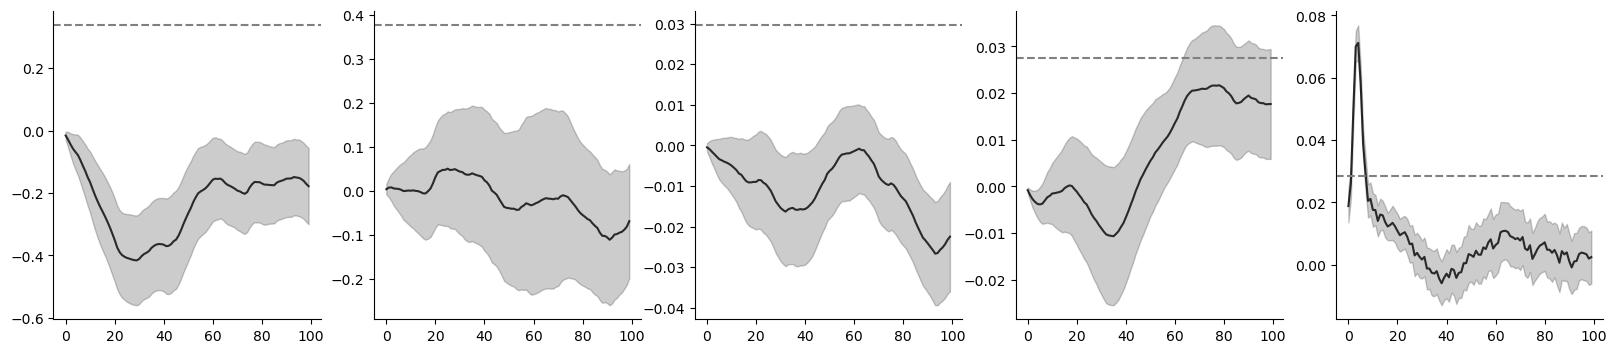

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False, sharex=True)
for ax, var in zip(axes, ['dc', 'freq', 'overlap', 'null', 'seq']):
    obs = np.sum(results[('obs', var)], axis=1) # sum across directions
    _u = np.mean(obs, axis=0) # average across subjects
    _err = stats.sem(obs, axis=0)
    
    ax.plot(_u, color='k', alpha=.8)
    ax.fill_between(np.arange(_u.shape[0]), _u - _err, _u + _err, alpha=0.2, color='k')
    
    null_dist = np.mean(results[('permutation', var)], axis=0).sum(axis=1).max(axis=-1) # average across subjects -> sum across directions -> max across lags
    threshold = np.percentile(null_dist, 95)
    ax.axhline(threshold, color='gray', linestyle='--')

    sns.despine(ax=ax)

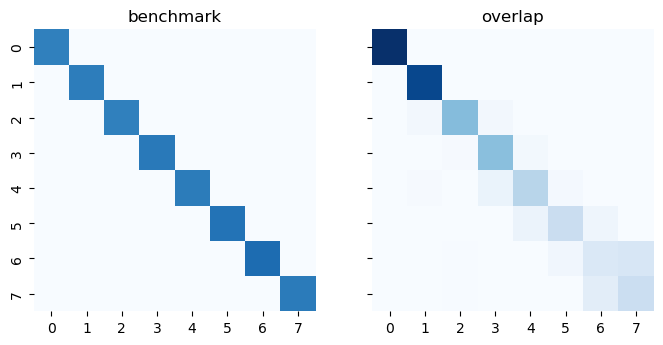

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)
for ax, var in zip(axes, ['benchmark', 'overlap']):
    cm = np.mean(group_cm[var], axis=0)
    cm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,  vmax=.8, vmin=.1, cbar=False, square=True)
    ax.set_title(var)